# Module 3 Mini-Project — Classification & Clustering

**Objective:** Complete an end-to-end ML workflow: data loading → EDA → preprocessing → classification → evaluation → clustering → conclusions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

display(df.head())
print("Shape:", df.shape)
display(df.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 1. Quick EDA

Missing values:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

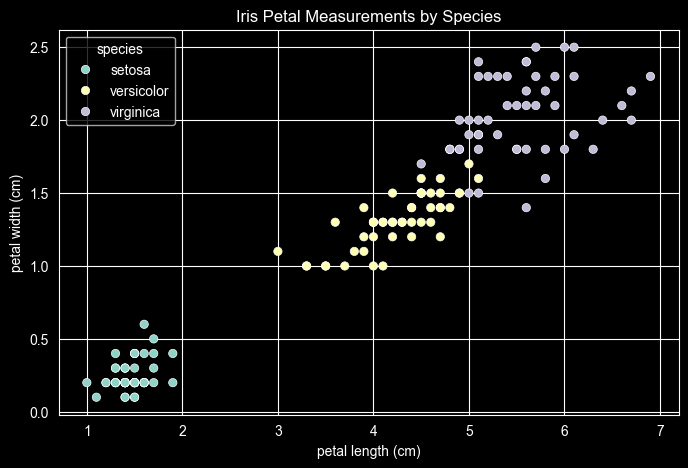

In [2]:
print("Missing values:")
display(df.isna().sum())

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)
plt.title("Iris Petal Measurements by Species")
plt.show()

## 2. Features and target

In [3]:
X = df[iris.feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3. Train multiple classifiers

In [4]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1": f1_score(y_test, pred, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
1,KNN,0.933333,0.944444,0.933333,0.932660
3,Random Forest,0.900000,0.902357,0.900000,0.899749


## 4. Confusion matrix for best model

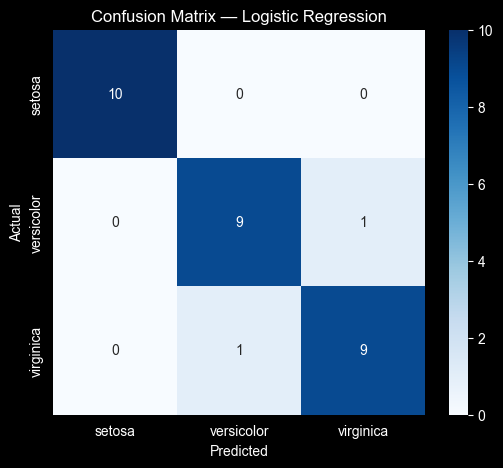

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [5]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

print(classification_report(y_test, best_pred, target_names=iris.target_names))

## 5. K-Means clustering

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print("Silhouette score:", round(silhouette_score(X_scaled, clusters), 4))
display(pd.crosstab(df["species"], df["cluster"]))

Silhouette score: 0.4599


cluster,0,1,2
species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


## 6. Visualize clusters

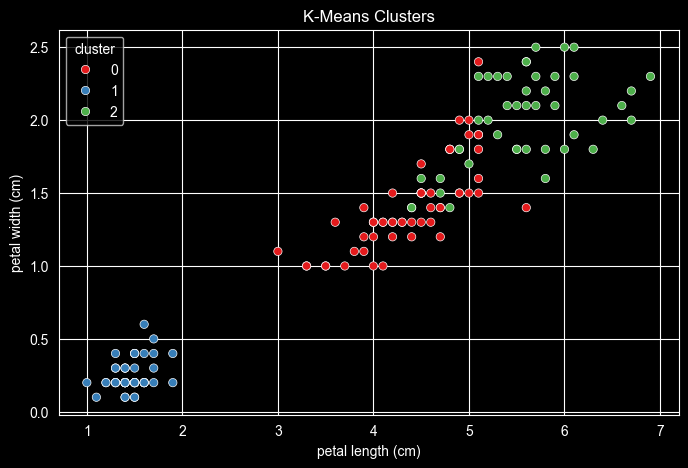

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="cluster",
    palette="Set1"
)
plt.title("K-Means Clusters")
plt.show()

## 7. Project conclusions

In [8]:
print(f"Best classifier: {best_name}")
print(f"Best F1 score: {results_df.iloc[0]['F1']:.4f}")
print("The classification models predict iris species from flower measurements.")
print("The confusion matrix shows which classes are correctly or incorrectly predicted.")
print("K-Means groups observations without using the known species labels.")
print("The silhouette score measures how well-separated the discovered clusters are.")

Best classifier: Logistic Regression
Best F1 score: 0.9333
The classification models predict iris species from flower measurements.
The confusion matrix shows which classes are correctly or incorrectly predicted.
K-Means groups observations without using the known species labels.
The silhouette score measures how well-separated the discovered clusters are.


## Final Summary

This mini-project demonstrates the complete supervised and unsupervised ML workflow: dataset exploration, train/test splitting, multiple classifiers, evaluation with accuracy/precision/recall/F1, confusion-matrix analysis, and K-Means clustering with silhouette evaluation.